### Postprocessing of data extracted by the Sniffer.

This notebook contains development scripts - most of this will be automated in the Sniffer: `run_postprocessing` will run following the full data extraction.

### TODO: add data types and physiological bounds to schema (and 'normal bounds'?). Add derived variables and forumlae? Add unit conversion functions?

#### TODO: add discharge time to schema (and run Sniffer with only this variable -> add to mapping and extract manually).
#### TODO: add functionality to append to a pre-existing schema or project, without having to redo the full mapping.

#### TODO: assign priority during attribute mapping/extraction

#### TODO: add ICNARC number to WW extract for better linkage.

In [24]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import timedelta
import os
os.chdir('../streamlit/')
from utilities import LocalDatabaseWrapper
os.chdir('../development')

# %matplotlib_inline

In [3]:
project_name = "smartt_bmj_open_plus"
database_path = Path("../data")

In [4]:
local_db = LocalDatabaseWrapper(
            database_path / f"{project_name}.db"
        )

In [5]:
# Already has been run!
# local_db.insert_query(
#     "CREATE INDEX intervention_attribute ON full_extract (interventionId, attributeId);"
# )

# local_db.insert_query(
#     "CREATE INDEX encounter ON full_extract (encounterId);"
# )

In [6]:
# Check that index has been added (if not, uncomment and run above cell).
local_db.query_pd("PRAGMA index_list('full_extract');")

,seq,name,unique,origin,partial
0,0,encounter,0,c,0
1,1,intervention_attribute,0,c,0


In [7]:
local_db.query_pd(
    "select * from sqlite_master where type = 'table';"
    
)

,type,name,tbl_name,rootpage,sql
0,table,schema,schema,2,"CREATE TABLE ""schema"" (\n""mapping_complete"" IN..."
1,table,info,info,5,"CREATE TABLE ""info"" (\n""name"" TEXT,\n ""databa..."
2,table,clinical_unit_ids,clinical_unit_ids,6,"CREATE TABLE ""clinical_unit_ids"" (\n""Select"" I..."
3,table,fact_table_init_status,fact_table_init_status,7,"CREATE TABLE ""fact_table_init_status"" (\n""tabl..."
4,table,PtAssessmentInterventions,PtAssessmentInterventions,9,"CREATE TABLE ""PtAssessmentInterventions"" (\n""i..."
5,table,PtLabResultInterventions,PtLabResultInterventions,79,"CREATE TABLE ""PtLabResultInterventions"" (\n""in..."
6,table,PtDemographicInterventions,PtDemographicInterventions,109,"CREATE TABLE ""PtDemographicInterventions"" (\n""..."
7,table,table_definitions,table_definitions,116,"CREATE TABLE ""table_definitions"" (\n""tableType..."
8,table,distinct_attributes,distinct_attributes,119,"CREATE TABLE ""distinct_attributes"" (\n""attribu..."
9,table,example_attribute_data,example_attribute_data,120,"CREATE TABLE ""example_attribute_data"" (\n""attr..."


In [8]:
final_mapping = local_db.query_pd(
    "select * from final_mapping;"
    
)
final_mapping 

,schemaVariable,interventionId,interventionLongLabel,priority,attributeId,attributeShortLabel,tableName
0,Gender,2631,Gender,0,11050,Gender,PtDemographic
1,BMI,2645,Body Mass Index,0,3723,BMI,PtDemographic
2,Weight,2110,Weight (admission),0,3588,Admit weight,PtDemographic
3,Weight,2110,Weight (admission),0,40554,Admit weight,PtDemographic
4,Weight,4615,Weight (Admission),0,1636,Weight,PtDemographic
...,...,...,...,...,...,...,...
138,Endotracheal tube,2316,ETT/Trache Cuff Inflated,0,6064,Cuff Inflated,PtAssessment
139,Endotracheal tube,25519,ETT/Trache Cuff Inflated,0,46466,Cuff Inflated,PtAssessment
140,Endotracheal tube,25519,ETT/Trache Cuff Inflated,0,46467,Pressure,PtAssessment
141,Endotracheal tube,70054,ETT/Trache Cuff Inflated,0,74755,Cuff Inflated,PtAssessment


In [459]:
for var in final_mapping.schemaVariable.unique():
    count = (final_mapping.schemaVariable==var).sum()
    final_mapping.loc[final_mapping.schemaVariable==var,'priority'] = range(count)

In [461]:
unique_variables = final_mapping.schemaVariable.unique()

In [462]:
len(unique_variables)

37

In [8]:
final_mapping[final_mapping.schemaVariable == unique_variables[20]]

,schemaVariable,interventionId,interventionLongLabel,priority,attributeId,attributeShortLabel,tableName
60,Heart rate,3361,Heart Rate,0,12754,HR,PtAssessment
61,Heart rate,7838,Heart Rate,0,27308,HR,PtAssessment
62,Heart rate,7838,Heart Rate,0,27309,HR,PtAssessment
63,Heart rate,7838,Heart Rate,0,27312,HR,PtAssessment


In [9]:
df = local_db.query_pd(
    "select * from full_extract where interventionId = 7838 and attributeId = 27312;"
)
df.valueNumber = pd.to_numeric(df.valueNumber)

In [10]:
len(df.encounterId.unique())

20679

In [17]:
df.valueNumber.mean()

np.float64(83.20417518431671)

In [33]:
df.valueNumber.isna().sum()

np.int64(1170)

In [35]:
df = df[~df.valueNumber.isna()]

#### The following should be expanded to check for physiological values and do any required unit conversions:

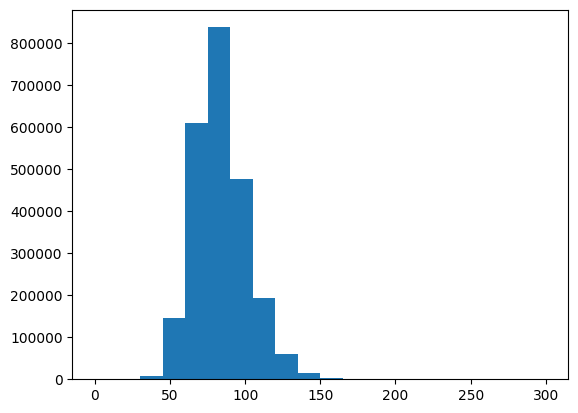

In [37]:
plt.hist(df.valueNumber, bins=20);

{'bodies': [<matplotlib.collections.PolyCollection at 0x210371f9190>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x210364fea90>,
 'cmins': <matplotlib.collections.LineCollection at 0x21037296bd0>,
 'cbars': <matplotlib.collections.LineCollection at 0x2103695bf10>}

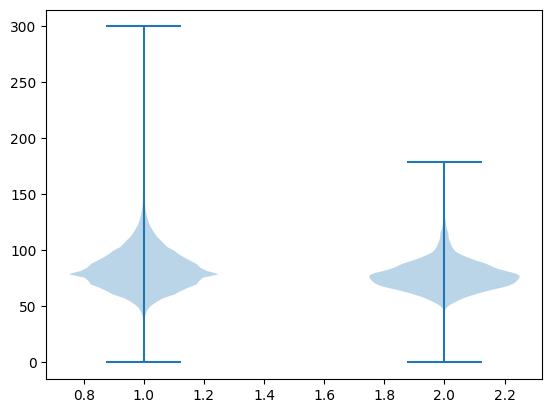

In [39]:
plt.violinplot([df.valueNumber, df.valueNumber.array[0:5000]], )

In [41]:
unique_variables

array(['Gender', 'BMI', 'Weight', 'Height', 'DOB', 'Ethnicity',
       'Postcode', 'Admit source', 'Hospital Number', 'Pao2',
       'actual bicarbonate', 'arterial oxygen saturation', 'Hemoglobin',
       'platelet count', 'Sodium', 'potassium', 'creatinine', 'urea',
       'C-reactive protein', 'Bilirubin', 'Heart rate',
       'arterial blood pressure (systolic)',
       'arterial blood pressure (diastolic)',
       'arterial blood pressure (mean)',
       'noninvasive blood pressure (systolic)',
       'noninvasive blood pressure (diastolic)', 'temperature', 'Fio2',
       'positive end-expiratory pressure', 'tidal volume',
       'respiratory rate', 'peripheral oxygen saturation',
       'Glasgow Coma Scale', 'Richmond Agitation-Sedation Scale',
       'Pao2/Fio2', 'Urine output', 'Endotracheal tube'], dtype=object)

In [42]:
local_db.query_pd(
    "select * from final_mapping where tableName='PtDemographic';"
    
)

,schemaVariable,interventionId,interventionLongLabel,priority,attributeId,attributeShortLabel,tableName
0,Gender,2631,Gender,0,11050,Gender,PtDemographic
1,BMI,2645,Body Mass Index,0,3723,BMI,PtDemographic
2,Weight,2110,Weight (admission),0,3588,Admit weight,PtDemographic
3,Weight,2110,Weight (admission),0,40554,Admit weight,PtDemographic
4,Weight,4615,Weight (Admission),0,1636,Weight,PtDemographic
5,Weight,4615,Weight (Admission),0,34296,Weight,PtDemographic
6,Weight,4615,Weight (Admission),0,34301,Weight,PtDemographic
7,Weight,8906,Weight (prescribing),0,33390,Weight,PtDemographic
8,Weight,8917,Weight (Prescribing),0,1636,Weight,PtDemographic
9,Weight,8917,Weight (Prescribing),0,34296,Weight,PtDemographic


In [188]:
admit_discharge_times = local_db.query_pd(
    """
    select encounterId, MIN(chartTime) as admitDateTime, MAX(chartTime) as dischargeDateTime, MIN(utcChartTime) as utcAdmitDateTime, MAX(utcChartTime) as utcDischargeDateTime, MIN(storeTime) as admitStoreDateTime, MAX(storeTime) as dischargeStoreDateTime from full_extract
    group by encounterId;
    """  
)

In [81]:
all_t_numbers = local_db.query_pd(
    "select * from full_extract where interventionId=2402 and attributeId=18476;"
    
)

In [190]:
admit_discharge_times

,encounterId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime
0,1,2014-12-31 02:35:00,2015-01-30 08:56:00,2014-12-31 02:35:00,2015-01-30 08:56:00,2015-01-30 08:56:00.927000,2015-01-30 16:22:11.377000
1,2,2015-01-28 12:29:00,2015-01-30 08:48:00,2015-01-28 12:29:00,2015-01-30 08:48:00,2015-01-30 08:48:35.880000,2015-01-30 08:49:53.073000
2,3,2015-01-30 08:55:00,2015-01-30 08:55:00,2015-01-30 08:55:00,2015-01-30 08:55:00,2015-01-30 08:55:56.460000,2015-01-30 08:55:56.867000
3,4,2015-01-30 08:52:00,2015-01-30 08:52:00,2015-01-30 08:52:00,2015-01-30 08:52:00,2015-01-30 08:52:36.463000,2015-01-30 08:52:36.863000
4,7,2015-01-30 08:56:00,2015-01-30 08:56:00,2015-01-30 08:56:00,2015-01-30 08:56:00,2015-01-30 08:56:42.760000,2015-01-30 08:56:43.210000
...,...,...,...,...,...,...,...
23495,37011,2023-08-08 18:27:00,2023-08-09 23:00:00,2023-08-08 17:27:00,2023-08-09 22:00:00,2023-08-09 10:54:44.893000,2023-08-09 22:58:10.330000
23496,37013,2023-07-24 15:16:00,2023-08-09 23:36:00,2023-07-24 14:16:00,2023-08-09 22:36:00,2023-08-09 12:27:15.870000,2023-08-09 23:38:57.300000
23497,37014,2023-08-09 13:42:00,2023-08-09 13:42:00,2023-08-09 12:42:00,2023-08-09 12:42:00,2023-08-09 13:43:07.760000,2023-08-09 13:43:07.760000
23498,37015,2023-08-09 13:51:00,2023-08-09 13:51:00,2023-08-09 12:51:00,2023-08-09 12:51:00,2023-08-09 13:51:55.757000,2023-08-09 13:51:55.773000


In [191]:
admit_discharge_times.admitDateTime = pd.to_datetime(admit_discharge_times.admitDateTime)
admit_discharge_times.dischargeDateTime = pd.to_datetime(admit_discharge_times.dischargeDateTime)

admit_discharge_times.utcAdmitDateTime = pd.to_datetime(admit_discharge_times.utcAdmitDateTime)
admit_discharge_times.utcDischargeDateTime = pd.to_datetime(admit_discharge_times.utcDischargeDateTime)

admit_discharge_times.admitStoreDateTime = pd.to_datetime(admit_discharge_times.admitStoreDateTime, format='mixed')
admit_discharge_times.dischargeStoreDateTime = pd.to_datetime(admit_discharge_times.dischargeStoreDateTime, format='mixed')

In [192]:
DAY_0 = admit_discharge_times.iloc[0].admitDateTime.date()

In [193]:
DAY_0

datetime.date(2014, 12, 31)

In [149]:
df.columns

Index(['attributeId', 'interventionId', 'encounterId', 'attributeShortLabel',
       'attributeLongLabel', 'clinicalUnitId', 'terseForm', 'verboseForm',
       'valueNumber', 'valueString', 'valueDateTime', 'unitOfMeasure',
       'chartTime', 'storeTime', 'utcChartTime', 'careProviderId',
       'tableTypeId', 'bedId', 'lowerNormal', 'upperNormal',
       'attributeConceptLabel', 'attributeConceptCode'],
      dtype='object')

In [194]:
# admit_discharge_times['admitDay'] = admit_discharge_times.admitDateTime.apply(
#     lambda x: (x.date() - DAY_0).days
# )
admit_discharge_times['admitDay'] = admit_discharge_times.admitStoreDateTime.apply(
    lambda x: (x.date() - DAY_0).days
)

In [195]:
# admit_discharge_times['dischargeDay'] = admit_discharge_times.dischargeDateTime.apply(
#     lambda x: (x.date() - DAY_0).days
# )
admit_discharge_times['dischargeDay'] = admit_discharge_times.dischargeStoreDateTime.apply(
    lambda x: (x.date() - DAY_0).days
)

In [196]:
icca_cohort = all_t_numbers[['encounterId', 'clinicalUnitId', 'valueString', 'bedId']].merge(admit_discharge_times, on='encounterId', how='inner')

In [197]:
icca_cohort.rename(columns={'valueString': 'Hospital number'}, inplace=True)

In [227]:
df.head()

,attributeId,interventionId,encounterId,attributeShortLabel,attributeLongLabel,clinicalUnitId,terseForm,verboseForm,valueNumber,valueString,...,chartTime,storeTime,utcChartTime,careProviderId,tableTypeId,bedId,lowerNormal,upperNormal,attributeConceptLabel,attributeConceptCode
0,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,75,75 bpm,75.0,None,...,2015-06-16 16:00:00,2015-06-16 16:00:34.287000,2015-06-16 15:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
1,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,74,74 bpm,74.0,None,...,2015-06-16 17:00:00,2015-06-16 17:00:11.627000,2015-06-16 16:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
2,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,76,76 bpm,76.0,None,...,2015-06-16 18:00:00,2015-06-16 18:00:15.640000,2015-06-16 17:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
3,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,75,75 bpm,75.0,None,...,2015-06-16 19:00:00,2015-06-16 19:00:13.877000,2015-06-16 18:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005
4,27312,7838,1583,HR,Heart Rate.HR.Heart Rate,5,78,78 bpm,78.0,None,...,2015-06-16 20:00:00,2015-06-16 20:00:15.323000,2015-06-16 19:00:00,4,4,35,50.0,120.0,Heart rate (observable entity),364075005


In [231]:
min_hr_chart = df.groupby('encounterId').agg({'chartTime': 'min'})

In [233]:
icca_cohort = icca_cohort.merge(min_hr_chart, on='encounterId', how='inner')

In [315]:
# icca_cohort['admitDay'] = pd.to_datetime(icca_cohort.chartTime).apply(
#     lambda x: (x.date() - DAY_0).days
# )
icca_cohort['admitDay'] = pd.to_datetime(icca_cohort.admitStoreDateTime).apply(
    lambda x: (x.date() - DAY_0).days
)

### Linking to ICNARC data:

In [431]:
icnarc_path = Path('E:\SMARTT\ward_watcher\discharge_data')
icnarc_file_1 = 'gicu_discharge_data_1990_2015.txt'
icnarc_file_2 = 'gicu_discharge_data_2015_2023.txt'

In [432]:
icnarc_data = pd.read_csv(icnarc_path / icnarc_file_1, delimiter='\t')

In [365]:
icnarc_data_2 = pd.read_csv(icnarc_path / icnarc_file_2, delimiter='\t')

In [366]:
icnarc_data = pd.concat([icnarc_data, icnarc_data_2])
icnarc_data.drop_duplicates(inplace=True)
icnarc_data.columns

Index(['NHS number', 'Hospital number', 'Date of birth', 'Unit admit date',
       'Unit admit time', 'Admission type',
       'Readmission during this hospital stay', 'Nature of surgery',
       'Primary reason for admission to Unit',
       'Declared clinically ready for discharge',
       'Clinically ready for discharge (date)',
       'Clinically ready for discharge (time)', 'Discharged/died on (date)',
       'Discharged/died at (time)', 'Unit stay (days)', 'Unit outcome',
       'Delay from request to discharge (mins)', 'Discharge delay abnormal',
       'Abnormal delay caused by', 'Destination (name)',
       'Date discharged from this hospital', 'Hospital sent to (name)',
       'Outcome on discharge from this hospital',
       'Days from Unit to hospital discharge',
       'Date of ultimate hospital discharge',
       'Ultimate hospital discharge to (name)',
       'Outcome on ultimate hospital discharge',
       'Days this hosp to ultimate discharge'],
      dtype='object')

In [292]:
icnarc_data = icnarc_data[~icnarc_data['Discharged/died on (date)'].isna()]

In [370]:
icnarc_data['Unit outcome'].unique()

array(['2. No change', '4. Died', '1. Improved', '3. Worse', nan],
      dtype=object)

In [293]:
icnarc_data['Outcome on discharge from this hospital'].unique()

array(['1. Lived', '2. Died', nan], dtype=object)

In [294]:
icnarc_data['Outcome on ultimate hospital discharge'].unique()

array(['1. Lived', '2. Died', nan], dtype=object)

In [295]:
icnarc_data['Declared clinically ready for discharge'].unique()

array(['No', nan, 'Yes'], dtype=object)

In [298]:
len(icnarc_data['Hospital number'].unique())

22171

In [299]:
len(icnarc_data)

25015

In [300]:
icnarc_data['Unit admit date'] = pd.to_datetime(icnarc_data['Unit admit date'], dayfirst=True)

In [301]:
icnarc_data['Clinically ready for discharge (date)'] = pd.to_datetime(icnarc_data['Clinically ready for discharge (date)'], dayfirst=True)

In [302]:
icnarc_data['Discharged/died on (date)'] = pd.to_datetime(icnarc_data['Discharged/died on (date)'], dayfirst=True)

In [303]:
icnarc_data['admitDay'] = icnarc_data['Unit admit date'].apply(
    lambda x: (x.date() - DAY_0).days
)

In [304]:
# icnarc_data.dischargeDay = icnarc_data['Discharged/died on (date)'].apply(
#     lambda x: (x.date() - DAY_0).days
# )

In [317]:
icca_cohort['Hospital number'] = icca_cohort['Hospital number'].astype(str).apply(lambda x: x.strip())

In [318]:
icnarc_data['Hospital number'] = icnarc_data['Hospital number'].astype(str).apply(lambda x: x.strip())

In [319]:
icnarc_data['icnarc_id'] = range(len(icnarc_data))

In [320]:
# linked_cohort = icnarc_data.merge(icca_cohort, on=['Hospital number', 'dischargeDay'], how='inner')
linked_cohort = icnarc_data.merge(icca_cohort, on=['Hospital number', 'admitDay'], how='inner')
# linked_cohort = icnarc_data.merge(icca_cohort, on='Hospital number', how='left')

#### Best linkage using admitStoreDateTime to define admission day using first storeTime entry:  (first HR entry also OK)

In [463]:
len(linked_cohort)

8269

In [322]:
linked_cohort.groupby('clinicalUnitId').count()

,NHS number,Hospital number,Date of birth,Unit admit date,Unit admit time,Admission type,Readmission during this hospital stay,Nature of surgery,Primary reason for admission to Unit,Declared clinically ready for discharge,...,encounterId,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,dischargeDay,chartTime
clinicalUnitId,,,,,,,,,,,,,,,,,,,,,
5,8139,8223,8223,8223,8223,8207,8207,8207,8205,6935,...,8223,8223,8223,8223,8223,8223,8223,8223,8223,8223
8,46,46,46,46,46,46,46,46,46,36,...,46,46,46,46,46,46,46,46,46,46


#### Large chunk without RFD flag: 
(We should still use these for training the new algo, unlike the original paper. Since many of these will be clear cases of NRFD - i.e. those with negative outcomes. Those with positives outcomes will be removed and synthetic labels added - we do not know if and when these patients were RFD.)

In [323]:
linked_cohort['Clinically ready for discharge (date)'].isna().sum()

np.int64(2852)

#### A few edge cases who are RFD before admission:
(These should be removed.)

In [464]:
linked_cohort[linked_cohort['Clinically ready for discharge (date)'] <= linked_cohort['admitStoreDateTime']]

,NHS number,Hospital number,Date of birth,Unit admit date,Unit admit time,Admission type,Readmission during this hospital stay,Nature of surgery,Primary reason for admission to Unit,Declared clinically ready for discharge,...,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,dischargeDay,chartTime,in_hospital_mortality,readmission
20,462 415 6153,T7846270,22/12/1990,2015-06-16,22:10:00,04. Planned local surgical admission,No,3. Scheduled,Bronchial tumour,Yes,...,2015-06-16 22:00:00,2015-06-17 12:00:00,2015-06-16 21:00:00,2015-06-17 11:00:00,2015-06-16 22:14:26.437,2015-06-17 13:17:53.713,168,2015-06-16 22:00:00,0,0
71,454 394 7495,T6165138,8/10/1953,2015-07-07,03:28:00,01. Unplanned local admission,No,2. Urgent,Primary peritonitis,Yes,...,2015-07-04 08:00:00,2015-07-08 09:56:00,2015-07-04 07:00:00,2015-07-08 08:56:00,2015-07-07 03:28:58.927,2015-07-08 11:28:48.833,189,2015-07-07 04:00:00,0,0
124,444 749 5376,T7888378,16/1/1952,2015-07-22,15:07:00,01. Unplanned local admission,No,Not relevant,Acute myocardial infarction,Yes,...,2015-07-22 13:34:00,2015-07-30 05:41:00,2015-07-22 12:34:00,2015-07-30 04:41:00,2015-07-22 15:08:23.140,2015-07-30 10:31:41.177,211,2015-07-22 15:00:00,0,0
125,612 270 0932,T6645546,14/9/1934,2015-07-22,16:43:00,04. Planned local surgical admission,No,3. Scheduled,Secondary hepatic tumour,Yes,...,2015-07-22 10:09:00,2015-07-23 06:41:00,2015-07-22 09:09:00,2015-07-23 05:41:00,2015-07-22 16:43:58.337,2015-07-23 10:21:32.343,204,2015-07-22 17:00:00,0,0
214,472 140 6029,T5313279,18/12/1938,2015-08-15,00:52:00,01. Unplanned local admission,No,1. Emergency,Ovarian tumour,Yes,...,2015-08-10 12:41:00,2015-08-19 08:00:00,2015-08-10 11:41:00,2015-08-19 07:00:00,2015-08-15 00:53:00.167,2015-08-19 11:11:36.807,231,2015-08-15 01:00:00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7432,432 675 3463,T8017170,16/1/1969,2021-12-23,00:30:00,01. Unplanned local admission,No,Not relevant,Acute alcoholic hepatitis,Yes,...,2021-12-22 17:44:00,2021-12-23 22:57:00,2021-12-22 17:44:00,2021-12-23 22:57:00,2021-12-23 00:30:26.340,2021-12-24 01:18:13.620,2550,2021-12-23 01:00:00,1,0
7433,454 188 8475,T5038950,26/9/1951,2021-12-23,06:23:19,01. Unplanned local admission,No,1. Emergency,Intra-peritoneal abscess (not pelvic),Yes,...,2021-12-16 09:51:00,2021-12-24 05:33:00,2021-12-16 09:51:00,2021-12-24 05:33:00,2021-12-23 04:03:32.623,2021-12-24 09:57:12.800,2550,2021-12-23 06:30:00,0,0
7521,476 402 9359,T6997741,16/3/1964,2022-02-05,00:09:00,04. Planned local surgical admission,No,4. Elective,"Pressure injury, ulcers or sores",Yes,...,2022-02-02 23:56:00,2022-02-05 12:00:00,2022-02-02 23:56:00,2022-02-05 12:00:00,2022-02-05 00:09:14.363,2022-02-05 12:35:16.563,2593,2022-02-05 00:00:00,0,0
7810,472 186 1192,T5999960,15/8/1939,2022-06-10,00:25:00,01. Unplanned local admission,No,2. Urgent,Ovarian cyst,Yes,...,2022-06-04 03:29:00,2022-06-11 08:00:00,2022-06-04 02:29:00,2022-06-11 07:00:00,2022-06-10 00:17:34.107,2022-06-11 14:32:22.397,2719,2022-06-10 01:00:00,0,0


In [494]:
final_cohort = linked_cohort[~(linked_cohort['Clinically ready for discharge (date)'] <= linked_cohort['admitStoreDateTime'])].copy()

#### Do CICU use ICNARC? We could substatnailly increase cohort size...

In [328]:
icca_cohort.groupby('clinicalUnitId').count()

,encounterId,Hospital number,bedId,admitDateTime,dischargeDateTime,utcAdmitDateTime,utcDischargeDateTime,admitStoreDateTime,dischargeStoreDateTime,admitDay,dischargeDay,chartTime
clinicalUnitId,,,,,,,,,,,,
5,9099,9099,9099,9099,9099,9099,9099,9099,9099,9099,9099,9099
8,11723,11723,11723,11723,11723,11723,11723,11723,11723,11723,11723,11723


In [329]:
len(icca_cohort)

20822

In [483]:
linked_cohort.columns

Index(['NHS number', 'Hospital number', 'Date of birth', 'Unit admit date',
       'Unit admit time', 'Admission type',
       'Readmission during this hospital stay', 'Nature of surgery',
       'Primary reason for admission to Unit',
       'Declared clinically ready for discharge',
       'Clinically ready for discharge (date)',
       'Clinically ready for discharge (time)', 'Discharged/died on (date)',
       'Discharged/died at (time)', 'Unit stay (days)', 'Unit outcome',
       'Delay from request to discharge (mins)', 'Discharge delay abnormal',
       'Abnormal delay caused by', 'Destination (name)',
       'Date discharged from this hospital', 'Hospital sent to (name)',
       'Outcome on discharge from this hospital',
       'Days from Unit to hospital discharge',
       'Date of ultimate hospital discharge',
       'Ultimate hospital discharge to (name)',
       'Outcome on ultimate hospital discharge',
       'Days this hosp to ultimate discharge', 'admitDay', 'icnarc_id',

In [495]:
final_cohort['Readmission during this hospital stay'].unique()

array(['No', 'Yes', nan], dtype=object)

In [496]:
final_cohort['Outcome on ultimate hospital discharge'].unique()

array(['2. Died', '1. Lived', nan], dtype=object)

In [497]:
final_cohort['readmission'] = [
    1 if r == 'Yes' 
    else 0
    for r in linked_cohort['Readmission during this hospital stay']
]

In [498]:
final_cohort['in_hospital_mortality'] = [
    1 if o == '2. Died' or u == '2. Died'
    else 0
    for o,u in zip(linked_cohort['Outcome on discharge from this hospital'], linked_cohort['Outcome on ultimate hospital discharge'])
]

In [499]:
final_cohort.readmission.sum() / len(linked_cohort)

np.float64(0.030366621404764843)

In [502]:
final_cohort.in_hospital_mortality.sum() / len(final_cohort)

np.float64(0.20997407727441056)

In [490]:
# pd.to_datetime(DAY_0)
# test = icnarc_data[pd.to_datetime(icnarc_data['Unit admit date']) > pd.to_datetime(DAY_0) ]
# test = test[pd.to_datetime(test['Unit admit date'], format='mixed') < pd.to_datetime('2017-01-01')]

test = icnarc_data[icnarc_data['Clinically ready for discharge (date)'].isna()]

# test = linked_cohort[linked_cohort['Unit admit date'] < '2020' ]

In [491]:
test['in_hospital_mortality'] = [
    1 if o == '2. Died' or u == '2. Died'
    else 0
    for o,u in zip(test['Outcome on discharge from this hospital'], test['Outcome on ultimate hospital discharge'])
]

C:\Users\mcwilliamschr\AppData\Local\Temp\13\ipykernel_28864\668789087.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['in_hospital_mortality'] = [


In [492]:
test.in_hospital_mortality.sum() / len(test)

np.float64(0.49609252891528605)

##### TODO: remove (or join?) duplicate encounterIds

In [710]:
readmission_this_stay = []

for ri, row in final_cohort.iterrows():
    # print(row.index)
    final_cohort.sort_values('admitStoreDateTime', ascending=True, inplace=True)
    this_patient = final_cohort[final_cohort['Hospital number']==row['Hospital number']].loc[ri:]
    if (len(this_patient) > 1) and (this_patient.iloc[1].admitStoreDateTime > this_patient.iloc[0].dischargeStoreDateTime):
        readmission_this_stay.append(1)
    else:
        readmission_this_stay.append(0)   

final_cohort['readmission_this_stay'] = readmission_this_stay

In [711]:
final_cohort['readmission_this_stay'].sum()

np.int64(767)

#### Note: is this too high? Some of these might be accidental 'discharges' from ICCA...

In [713]:
767 / len(final_cohort)

0.09467966917664486

In [722]:
final_cohort['outcome'] = 1 - (final_cohort['readmission_this_stay'] | final_cohort['in_hospital_mortality'])

In [ ]:
rfd_datetime = []
for ri, row in final_cohort.iterrows():
    if pd.isna(row['Clinically ready for discharge (time)']):
        rfd_datetime.append(np.nan)
    else:
        rfd_datetime.append(
            datetime.combine(row['Clinically ready for discharge (date)'], pd.to_datetime(row['Clinically ready for discharge (time)']).time())
        )
final_cohort['rfd_datetime'] = rfd_datetime

In [748]:
final_cohort.to_json('..\data\processed\linked_cohort_181024.json')

### Feature processing:

#### What we are aiming for is a completed timeseries of all variables for each patient. This should have rows corresponding to time steps at the required frequency (every 4 hours?) and columns corresponding to each schema variable. There should be one column for the raw variable data (with only actual records present at the time they were recorded), and another completed column with forward-fill/imputation. Where two simultaneous varaible records are present, the priority column should be used to select a single value. There should be a column with the actual datetime of the row, and another with hours since admission, and perhaps another with hours before discharge.    

## TODO:
* rounding chartTime to nearest hour : OK or should it be round up?
* process one patients at a time, in a loop, and save process timeseries to disk

In [517]:
final_cohort.encounterId.iloc[1000]

np.int64(5269)

In [521]:
schema = local_db.query_pd(
    "select * from schema;"
)

In [526]:
# Variables that are only recorded once
demographic_variables = schema[schema['Time Series']==0]
# Time Series variables:
time_series_variables = schema[schema['Time Series']==1]

In [527]:
time_series_variables

,mapping_complete,Variable,Simple name,Search Strings,Likely ICCA table,Possibly derived,Time Series,Pacmed ontology,Snowmed CT,Notes
10,1,Pao2,pao2,"pao2, o2, oxygen",PtLabResults,0,1,Laboratory_results.Blood_gas_analysis,None,None
11,1,actual bicarbonate,hco3,"bicarbonate, hco3, bicarb, co2, carbon dioxide",PtLabResults,0,1,Laboratory_results.Blood_gas_analysis,None,None
12,1,arterial oxygen saturation,so2,"saturation, sao2, so2, o2sat",PtLabResults,0,1,Laboratory_results.Blood_gas_analysis,None,Should we include/combine SpO2 in this variabl...
13,1,Hemoglobin,haemoglobin,"hemoglobin, haemoglobin, hb",PtLabResults,0,1,Laboratory_results.Hematology,None,None
14,1,platelet count,platelets,"platelet, thrombocyte",PtLabResults,0,1,Laboratory_results.Hematology,None,None
15,1,Sodium,na,"na, sodium",PtLabResults,0,1,Laboratory_results.Routine_chemistry,None,None
16,1,potassium,k,"potassium, K",PtLabResults,0,1,Laboratory_results.Routine_chemistry,None,None
17,1,creatinine,creatinine,"creatinine, cr, scr",PtLabResults,0,1,Laboratory_results.Routine_chemistry,None,None
18,1,urea,urea,"urea, BUN, ureum",PtLabResults,0,1,Laboratory_results.Routine_chemistry,None,None
19,1,C-reactive protein,crp,"crp, c-reactive, protein",PtLabResults,0,1,Laboratory_results.Routine_chemistry,None,None


In [575]:
EID = 1583

In [586]:
df = local_db.query_pd(
    f"select * from full_extract where encounterId = {EID};"
)

### TODO: here taking first, but should really use priority column..

In [588]:
final_cohort[final_cohort.encounterId == EID].iloc[0].admitStoreDateTime #+ timedelta(hours=1)

Timestamp('2015-04-22 02:56:30.483000')

In [590]:
# Various options for choice of admission time. Here we use the first storeTime for the ecnounter in ICCA (which is also used for linkage to ICNARC).
df['chartTime'] = pd.to_datetime(df['chartTime'])
# df['chartTimeRounded'] = df['chartTime'].round('h')
# min_hour = df.chartTime.min().round('h')

min_hour = final_cohort[final_cohort.encounterId == EID].iloc[0].admitStoreDateTime.round('h')
df['hours_since_admission'] = [(t - min_hour).total_seconds() / (60**2) for t in df.chartTime]

In [594]:
df = df.merge(final_mapping, on=['interventionId', 'attributeId'])

In [595]:
df.columns

Index(['attributeId', 'interventionId', 'encounterId', 'attributeShortLabel_x',
       'attributeLongLabel', 'clinicalUnitId', 'terseForm', 'verboseForm',
       'valueNumber', 'valueString', 'valueDateTime', 'unitOfMeasure',
       'chartTime', 'storeTime', 'utcChartTime', 'careProviderId',
       'tableTypeId', 'bedId', 'lowerNormal', 'upperNormal',
       'attributeConceptLabel', 'attributeConceptCode',
       'hours_since_admission', 'schemaVariable', 'interventionLongLabel',
       'priority', 'attributeShortLabel_y', 'tableName'],
      dtype='object')

In [596]:
df_grouped = df.groupby(['hours_since_admission', 'schemaVariable']).agg('first')

### We now turn this into a complete timeseries dataframe:

Note: currently using every hour - allows more downstream options.

In [600]:
max_time = df.chartTime.max().round('h')
admit_time = final_cohort[final_cohort.encounterId == EID].iloc[0].admitStoreDateTime.round('h')

In [659]:
encounter_series = pd.DataFrame({
    'time': [
        admit_time + timedelta(hours=i)
        for i in range(int((max_time - admit_time).total_seconds() / 60**2))
    ],
    'hours_since_admission': [
        float(i)
        for i in range(int((max_time - admit_time).total_seconds() / 60**2))
    ]
})

In [660]:
COL = 'terseForm'

In [662]:
keep_columns = ['time', 'hours_since_admission'] 
for var in time_series_variables.Variable:
    # print(var)
    encounter_series = pd.merge_asof(
        encounter_series, 
        df_grouped.reset_index()[df_grouped.reset_index()['schemaVariable']==var], 
        on='hours_since_admission',
        direction='backward',
        tolerance=1
    )[keep_columns + [COL]].rename(columns={COL:var})
    keep_columns.append(var)

Pao2
actual bicarbonate
arterial oxygen saturation
Hemoglobin
platelet count
Sodium
potassium
creatinine
urea
C-reactive protein
Bilirubin
Heart rate
arterial blood pressure (systolic)
arterial blood pressure (diastolic)
arterial blood pressure (mean)
noninvasive blood pressure (systolic)
noninvasive blood pressure (diastolic)
temperature
Fio2
positive end-expiratory pressure
tidal volume
respiratory rate
peripheral oxygen saturation
Glasgow Coma Scale
Richmond Agitation-Sedation Scale
Pao2/Fio2
Urine output
Endotracheal tube


In [670]:
fill_colums = [
    c
    for c in encounter_series.columns
    if c not in ['time', 'hours_since_admission']
]

In [676]:
pd.set_option('future.no_silent_downcasting', True)
for col in fill_colums:
    encounter_series[col + '_ffill'] = encounter_series[col].ffill().infer_objects(copy=False)

In [679]:
encounter_series.to_csv(f'../data/processed/{project_name}/{EID}_encounter_series.csv')

### We now run the above for all encounters:

##### Note: we use forward fill here, but this still has some NaNs where the variables is missing completely or missing at the start of the series. We also include the raw variable columns so that alternative imputation methods can be used. 

We also add the outcome label at each time point according to:
- if encounter has negative outcome (0): label is 0 always
- if encounter has a discharge timestamp and positive outcome, label is 1 from timestamp onwards
- if encounter has no discharge timestamp and positive outcome, label is 1 at end.

In [686]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")

In [689]:
final_cohort.columns

Index(['NHS number', 'Hospital number', 'Date of birth', 'Unit admit date',
       'Unit admit time', 'Admission type',
       'Readmission during this hospital stay', 'Nature of surgery',
       'Primary reason for admission to Unit',
       'Declared clinically ready for discharge',
       'Clinically ready for discharge (date)',
       'Clinically ready for discharge (time)', 'Discharged/died on (date)',
       'Discharged/died at (time)', 'Unit stay (days)', 'Unit outcome',
       'Delay from request to discharge (mins)', 'Discharge delay abnormal',
       'Abnormal delay caused by', 'Destination (name)',
       'Date discharged from this hospital', 'Hospital sent to (name)',
       'Outcome on discharge from this hospital',
       'Days from Unit to hospital discharge',
       'Date of ultimate hospital discharge',
       'Ultimate hospital discharge to (name)',
       'Outcome on ultimate hospital discharge',
       'Days this hosp to ultimate discharge', 'admitDay', 'icnarc_id',

### TODO: add demographic (and derived/string?) features when producing encounter_series files for all patients.

In [868]:
rfd_na = 0
for ei, EID in enumerate(final_cohort.encounterId.unique()):
    
    df = local_db.query_pd(
        f"select * from full_extract where encounterId = {EID};"
    )
    df['chartTime'] = pd.to_datetime(df['chartTime'])
    min_hour = final_cohort[final_cohort.encounterId == EID].iloc[0].admitStoreDateTime.round('h')
    df['hours_since_admission'] = [(t.round('h') - min_hour).total_seconds() / (60**2) for t in df.chartTime]
    df = df.merge(final_mapping, on=['interventionId', 'attributeId'])
    df_grouped = df.groupby(['hours_since_admission', 'schemaVariable']).agg('first')

    max_time = df.chartTime.max().round('h')
    admit_time = final_cohort[final_cohort.encounterId == EID].iloc[0].admitStoreDateTime.round('h')
    rfd_time = final_cohort[final_cohort.encounterId == EID].iloc[0].rfd_datetime.round('h')
    outcome = final_cohort[final_cohort.encounterId == EID].iloc[0].outcome

    encounter_series = pd.DataFrame({
        'time': [
            admit_time + timedelta(hours=i)
            for i in range(int((max_time - admit_time).total_seconds() / 60**2))
        ],
        'hours_since_admission': [
            float(i)
            for i in range(int((max_time - admit_time).total_seconds() / 60**2))
        ]
    })

    keep_columns = ['time', 'hours_since_admission'] 
    for var in time_series_variables.Variable:
        encounter_series = pd.merge_asof(
            encounter_series, 
            df_grouped.reset_index()[df_grouped.reset_index()['schemaVariable']==var], 
            on='hours_since_admission',
            direction='backward',
            tolerance=1
        )[keep_columns + [COL]].rename(columns={COL:var})
        keep_columns.append(var)

    for col in fill_colums:
        encounter_series[col + '_ffill'] = encounter_series[col].ffill().infer_objects(copy=False)

    # add outcome labels:
    if outcome == 0:
        encounter_series['label'] = [0 for i in range(len(encounter_series))]
    elif pd.isna(rfd_time):
        rfd_na+= 1
        encounter_series['label'] = [0 for i in range(len(encounter_series) - 1)] + [1]
    else:
        encounter_series['label'] = [
            t >= rfd_time.round('h')
            for t in encounter_series.time
        ]

    print(ei, EID, encounter_series['label'].sum(), encounter_series['label'].sum() / len(encounter_series))
    encounter_series.to_csv(save_to_path / f"{EID}_encounter_series.csv")
    if ei > 500:
        break

print(rfd_na)

0 1583 0 0.0
1 1924 1 0.0012836970474967907
2 1946 1 0.0016501650165016502
3 1972 0 0.0
4 2050 22 0.023991275899672846
5 2059 0 0.0
6 2060 21 0.061764705882352944
7 2069 0 0.0
8 2078 0 0.0
9 2084 8 0.010296010296010296
10 2092 25 0.1984126984126984
11 2096 28 0.08974358974358974
12 2100 0 0.0
13 2111 6 0.05714285714285714
14 2124 25 0.07204610951008646
15 2125 0 0.0
16 2129 33 0.6226415094339622
17 2134 9 0.375
18 2142 0 0.0
19 2143 6 0.2727272727272727
20 2145 0 0.0
21 2146 18 0.5625
22 2157 1 0.008928571428571428
23 2159 0 0.0
24 2161 0 0.0
25 2162 4 0.10810810810810811
26 2168 15 0.4411764705882353
27 2170 0 0.0
28 2171 22 0.07534246575342465
29 2173 23 0.5348837209302325
30 2177 1 0.009615384615384616
31 2180 0 0.0
32 2181 18 0.3
33 2184 18 0.34615384615384615
34 2185 0 0.0
35 2196 3 0.15789473684210525
36 2197 48 0.8571428571428571
37 2198 7 0.04487179487179487
38 2202 9 0.09090909090909091
39 2209 0 0.0
40 2214 0 0.0
41 2219 0 0.0
42 2222 1 0.00273224043715847
43 2228 1 0.0370370

In [779]:
final_cohort.drop_duplicates(subset='encounterId', keep='first', inplace=True)

In [847]:
test_cohort = final_cohort.sample(frac=0.2, random_state=42)

In [848]:
train_cohort = final_cohort[~final_cohort.index.isin(test_cohort.index)]

In [849]:
(~train_cohort['Declared clinically ready for discharge'].isna()).sum()

np.int64(5413)

In [850]:
rfd = encounter_series.time.iloc[-10]

In [851]:
rfd

Timestamp('2023-02-13 01:00:00')

In [852]:
outcome = final_cohort[final_cohort.encounterId==EID].outcome.iloc[0]

In [853]:
outcome

np.int64(1)

In [854]:
sample_times = []
t = rfd.round('h')
while t >= (final_cohort[final_cohort.encounterId==EID].admitStoreDateTime.iloc[0] + timedelta(hours=48)):
    sample_times.append(t)
    t -= timedelta(hours=24)

In [855]:
final_cohort.columns

Index(['NHS number', 'Hospital number', 'Date of birth', 'Unit admit date',
       'Unit admit time', 'Admission type',
       'Readmission during this hospital stay', 'Nature of surgery',
       'Primary reason for admission to Unit',
       'Declared clinically ready for discharge',
       'Clinically ready for discharge (date)',
       'Clinically ready for discharge (time)', 'Discharged/died on (date)',
       'Discharged/died at (time)', 'Unit stay (days)', 'Unit outcome',
       'Delay from request to discharge (mins)', 'Discharge delay abnormal',
       'Abnormal delay caused by', 'Destination (name)',
       'Date discharged from this hospital', 'Hospital sent to (name)',
       'Outcome on discharge from this hospital',
       'Days from Unit to hospital discharge',
       'Date of ultimate hospital discharge',
       'Ultimate hospital discharge to (name)',
       'Outcome on ultimate hospital discharge',
       'Days this hosp to ultimate discharge', 'admitDay', 'icnarc_id',

In [856]:
encounter_series[encounter_series.time.isin(sample_times)]

,time,hours_since_admission,Pao2,actual bicarbonate,arterial oxygen saturation,Hemoglobin,platelet count,Sodium,potassium,creatinine,...,positive end-expiratory pressure_ffill,tidal volume_ffill,respiratory rate_ffill,peripheral oxygen saturation_ffill,Glasgow Coma Scale_ffill,Richmond Agitation-Sedation Scale_ffill,Pao2/Fio2_ffill,Urine output_ffill,Endotracheal tube_ffill,label
60,2023-02-11 01:00:00,60.0,11.20,24.1,97.1,NaN,NaN,137,5.4,NaN,...,10.0,450,17,97,3,-5,37,NaN,Yes,0
84,2023-02-12 01:00:00,84.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,156,32,98,3,-5,27,NaN,Yes,0
108,2023-02-13 01:00:00,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,427,22,96,3,-5,31,NaN,Yes,0


In [14]:
original_features = [
    'Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial blood pressure (mean)_ffill', 'Fio2_ffill',
    'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'actual bicarbonate_ffill',
    'Hemoglobin_ffill', 'platelet count_ffill', 'Sodium_ffill', 'potassium_ffill',
    'creatinine_ffill', 'urea_ffill', 'Bilirubin_ffill', 'positive end-expiratory pressure_ffill'
]

In [15]:
new_features = [
    c
    for c in encounter_series.columns
    if '_ffill' in c and c not in original_features and 'trach' not in c and 'delta' not in c
]

In [16]:
all_features = original_features + new_features

In [858]:
encounter_series[encounter_series.time.isin(sample_times)][
    ['time', 'hours_since_admission'] + original_features
]

,time,hours_since_admission,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,actual bicarbonate_ffill,Hemoglobin_ffill,platelet count_ffill,Sodium_ffill,potassium_ffill,creatinine_ffill,urea_ffill,Bilirubin_ffill,positive end-expiratory pressure_ffill
60,2023-02-11 01:00:00,60.0,3,36.4,82,30,97.1,17,102,24.1,108,227,137,5.4,94,9.1,9,10.0
84,2023-02-12 01:00:00,84.0,3,38.1,71,35,97.7,32,105,22.7,118,171,140,4.5,68,7.7,14,10.0
108,2023-02-13 01:00:00,108.0,3,38.4,65,35,96.4,22,133,23.8,94,189,140,4.9,174,17.9,16,10.0


#### Note: forward fill is not appropriate here (and in many cases) - e.g. this patient is no longer ventilated, but has a forward-filled PEEP. Also, things like GCS may not be recorded if the patient it well. So filling the last value masks this.

In [942]:
sum([
    (d.total_seconds() / 60**2) < 12
    for d in (final_cohort.dischargeStoreDateTime - final_cohort.admitStoreDateTime)
])

191

In [1]:
def compute_temporal_features(sample_time, encounter_series, variable_columns):
    """
    Compute temporal features for specific variable columns (by default all _ffill features).

    delta_1: change in variable value over the past 24 hours (or less if los < 24)
    delta_2: change in variable value over the first 24 hours (or less if los < 24)
    delta_3: change in variable value over los
    """
    if sample_time not in encounter_series.time.values:
        return {
            f"{var}_delta_{i}": np.nan
            for var in variable_columns
            for i in [1,2,3]
        }
        
    min_time = encounter_series.time.min()

    delta_1_time = max(
        sample_time - timedelta(hours=24),
        min_time
    )
    delta_2_time = min(
        min_time + timedelta(hours=24),
        sample_time
    )
    delta_3_time = min_time
    
    sample_time_row = encounter_series[encounter_series.time==sample_time].iloc[0]

    temporal_feature_values = {}
    for var in variable_columns:
        temporal_feature_values[f"{var}_delta_1"] = sample_time_row[var] - encounter_series[encounter_series.time==delta_1_time].iloc[0][var]
        temporal_feature_values[f"{var}_delta_2"] = encounter_series[encounter_series.time==delta_2_time].iloc[0][var] - encounter_series[encounter_series.time==min_time].iloc[0][var]
        temporal_feature_values[f"{var}_delta_3"] = sample_time_row[var] - encounter_series[encounter_series.time==delta_3_time].iloc[0][var]

    return temporal_feature_values
    

In [25]:
all_samples = None
rfd_na = 0
rfd_end = 0
D = 0
for ei, eid in enumerate(final_cohort.encounterId):

    if ei % 100 == 0:
        print(ei, eid)
    # if ei > 100:
    #     break
    encounter_series = pd.read_csv(save_to_path / f"{eid}_encounter_series.csv")
    encounter_series.time = pd.to_datetime(encounter_series.time)
    for f in all_features:
        encounter_series[f] = pd.to_numeric(encounter_series[f], errors='coerce')

    # fill any NaNs in first row, with second row value:
    srid = 1 if len(encounter_series) > 1 else 0
    encounter_series = encounter_series.apply(lambda x: x.fillna(value=encounter_series.iloc[srid,:]))
    
    rfd = final_cohort[final_cohort.encounterId==eid].rfd_datetime.iloc[0].round('h')
    admit_time = final_cohort[final_cohort.encounterId==eid].admitStoreDateTime.iloc[0].round('h')
    
    if not pd.isna(rfd):
        if rfd > encounter_series.time.max():
                rfd_end += 1
                rfd = encounter_series.time.max()
            
        sample_times = []
        t = rfd
        sample_times.append(t)
        t -= timedelta(hours=24)
        while t >= (admit_time + timedelta(hours=48)):
            sample_times.append(t)
            t -= timedelta(hours=24)

        view = encounter_series[encounter_series.time.isin(sample_times)].copy()
        view['eid'] = eid
        view['outcome'] = final_cohort[final_cohort.encounterId==eid].outcome.iloc[0]

        # add temporal features
        temp_feat = pd.DataFrame.from_records([
            compute_temporal_features(s, encounter_series, original_features)
            for s in sample_times
        ])
        for col in temp_feat.columns:
            view[col] = temp_feat[col].values
        
        delta = len(sample_times) - len(view)
        D += delta
        # if delta > 0:
            # print('not all sample times found')
            # break
        if all_samples is None:
            all_samples = view
        else:
            all_samples = pd.concat([all_samples, view])
    else:
        rfd_na+=1

# print(rfd_na)
# print(D)
# print(rfd_end)

0 1583


C:\Users\mcwilliamschr\AppData\Local\Temp\13\ipykernel_34188\2458773888.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  encounter_series = encounter_series.apply(lambda x: x.fillna(value=encounter_series.iloc[srid,:]))
C:\Users\mcwilliamschr\AppData\Local\Temp\13\ipykernel_34188\2458773888.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  encounter_series = encounter_series.apply(lambda x: x.fillna(value=encounter_series.iloc[srid,:]))
C:\Users\mcwilliamschr\AppData\Local\Temp\13\ipykernel_34188\2458773888.py:18: FutureWarning: Downcasting object

TypeError: 'str' object cannot be interpreted as an integer

In [1010]:
all_samples.to_csv(save_to_path / f"all_24hr_samples_final_cohort_.csv")

In [1011]:
all_samples.groupby(['label']).count()

,Unnamed: 0,time,hours_since_admission,Pao2,actual bicarbonate,arterial oxygen saturation,Hemoglobin,platelet count,Sodium,potassium,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
0,16796,16796,16796,7843,5854,7838,1275,460,8074,8074,...,5935,16627,5946,5946,13644,5163,4829,14062,4055,4055
1,4129,4129,4129,949,831,952,197,111,1032,1030,...,1444,3598,1446,1446,2978,1215,1160,1787,650,650


In [933]:
all_samples.groupby('label').count()

,Unnamed: 0,time,hours_since_admission,Pao2,actual bicarbonate,arterial oxygen saturation,Hemoglobin,platelet count,Sodium,potassium,...,tidal volume_ffill,respiratory rate_ffill,peripheral oxygen saturation_ffill,Glasgow Coma Scale_ffill,Richmond Agitation-Sedation Scale_ffill,Pao2/Fio2_ffill,Urine output_ffill,Endotracheal tube_ffill,eid,outcome
label,,,,,,,,,,,,,,,,,,,,,
0,16796,16796,16796,7843,5854,7838,1275,460,8074,8074,...,13982,16794,16794,16792,16781,14860,16,6645,16796,16796
1,4129,4129,4129,949,831,952,197,111,1032,1030,...,1874,4128,4127,4129,4097,2447,0,903,4129,4129


In [929]:
all_samples.groupby(['outcome', 'label']).count()['eid']

outcome  label
0        0         4012
1        0        12784
         1         4129
Name: eid, dtype: int64

In [930]:
len(all_samples.eid.unique())

5213

### We now do the same feature sampling, but we take every 4 hours from 12 hours post-admission until discharge at standard time points (10:00, 14:00, 18:00, 22:00, 02:00, 06:00). 

Every hour would likely result in too many identical or-near identical smaples. And we need standardised time points with a view to deployment.

In [40]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")
final_cohort = pd.read_json(
    '..\data\processed\linked_cohort_181024.json',
    convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime']
)

In [30]:
pd.set_option('future.no_silent_downcasting', True)

In [54]:
start_hours_post_admission = 12
sample_freq = 4
all_samples = None
bc = 0
for ei, eid in enumerate(final_cohort.encounterId):

    if ei % 100 == 0:
        print(ei, eid)
    # if bc > 100:
    #     break
    encounter_series = pd.read_csv(save_to_path / f"{eid}_encounter_series.csv")
    encounter_series.time = pd.to_datetime(encounter_series.time)
    for f in all_features:
        encounter_series[f] = pd.to_numeric(encounter_series[f], errors='coerce')

    # fill any NaNs in first row, with second row value:
    srid = 1 if len(encounter_series) > 1 else 0
    encounter_series = encounter_series.apply(lambda x: x.fillna(value=encounter_series.iloc[srid,:]))
    
    # rfd = final_cohort[final_cohort.encounterId==eid].rfd_datetime.iloc[0].round('h')
    admit_time = final_cohort[final_cohort.encounterId==eid].admitStoreDateTime.iloc[0].round('h')
    discharge_time = final_cohort[final_cohort.encounterId==eid].dischargeStoreDateTime.iloc[0].round('h')
       
    sample_times = []
    t = admit_time + timedelta(hours=start_hours_post_admission)
    sample_times.append(t)
    t += timedelta(hours=sample_freq)
    while t <= (discharge_time):
        sample_times.append(t)
        t += timedelta(hours=sample_freq)

    view = encounter_series[encounter_series.time.isin(sample_times)].copy()
    view['eid'] = eid
    view['outcome'] = final_cohort[final_cohort.encounterId==eid].outcome.iloc[0]

    if len(view) > 0:
        bc += 1
        # add temporal features
        temp_feat = pd.DataFrame.from_records([
            compute_temporal_features(s, encounter_series, original_features)
            for s in view.time
        ])
        for col in temp_feat.columns:
            view[col] = temp_feat[col].values
        
        if all_samples is None:
            all_samples = view
        else:
            all_samples = pd.concat([all_samples, view])
    else:
        print(f"No values found at sample times: {eid}")

0 1583
No values found at sample times: 2389
100 2399
No values found at sample times: 2451
No values found at sample times: 2465
No values found at sample times: 2505
No values found at sample times: 2595
200 2711
No values found at sample times: 2741
300 3003
No values found at sample times: 3022
No values found at sample times: 3083
No values found at sample times: 3165
No values found at sample times: 3224
400 3327
No values found at sample times: 3329
No values found at sample times: 3433
No values found at sample times: 3583
No values found at sample times: 3584
500 3628
No values found at sample times: 3628
No values found at sample times: 3756
No values found at sample times: 3773
600 3946
No values found at sample times: 4161
700 4234
No values found at sample times: 4467
800 4509
No values found at sample times: 4626
No values found at sample times: 4769
No values found at sample times: 4790
900 4837
No values found at sample times: 5041
No values found at sample times: 5108


In [55]:
all_samples.to_csv(save_to_path / f"all_{sample_freq}hr_samples_from_{start_hours_post_admission}_hours_final_cohort_.csv")

In [56]:
all_samples.groupby(['label']).count()

,Unnamed: 0,time,hours_since_admission,Pao2,actual bicarbonate,arterial oxygen saturation,Hemoglobin,platelet count,Sodium,potassium,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
0,249941,249941,249941,127578,94779,127385,33494,22701,137405,137323,...,87482,228733,87619,87619,192880,75245,71341,185595,61677,61677
1,26826,26826,26826,2706,2753,2705,1238,1093,3607,3599,...,9120,25696,9115,9115,21471,7753,7302,12818,4055,4055
